In [1]:
import RandomTilings as RT
from numpy import array
from matplotlib.collections import PolyCollection,PatchCollection
from matplotlib.patches import Polygon
from RandomTilings._draw_lozenges import compute_hexagon_data,in_hexagon,points_lozenge
from matplotlib.pyplot import subplots

In [2]:
def in_hexagon_border(x,y,A,B,C):
    return x == 1 or x == 2 or x == 2*(B+C)-1 or x == 2*(B+C)-2\
        or y == 1 or y == 2 or y == 2*(A+C)-1 or y == 2*(A+C)-2\
        or y == 2*A+x-1 or y == 2*A+x-2 or y == x-2*B+1 or y == x-2*B+2

def temperley_paths_start_points(M,A,B,C,dir):
    N = M.shape[0]
    start_points = [[0,0]]
    for x in range(1,N+1):
        for y in range(1,N+1):
            if in_hexagon(x,y,A,B,C) and M[N-y,x-1] == 1:
                if dir == 'east':
                    if x == 2*(B+C)-1:
                        start_points.append([x,y])
                elif dir == 'west':
                    if x == 1:
                        start_points.append([x,y])
    return start_points[1:]

def draw_temperley_paths(M,A,B,C,gap=False,edge_width=0,path_width=0,dot_width=0,gap_width=0,
                  shape='regular',color_scheme='standard',dpi=100):
    # Set matplotlib figure layout
    fig,ax = subplots(dpi=dpi)
    margin = 1
    if shape == 'regular':
        ax.set_xlim(-margin,2*(B+C)+margin)
        ax.set_ylim(-B-margin,2*A+C+margin)
        ax.set_aspect(2/(3**0.5))
    elif shape == 'skewed':
        ax.set_xlim(-margin,2*(B+C)+margin)
        ax.set_ylim(-margin,2*(A+C)+margin)
        ax.set_aspect('equal')
    else:
        print('Shape not recognized.')
        raise
    ax.axis('off')

    # Set color scheme
    color = array([[1,1,1],[1,1,1],[1,1,1]])

    # Computing data
    P,L = compute_hexagon_data(M,A,B,C,shape=='regular',path_width>0)

    # Plotting
    ax.add_collection(PolyCollection(P,facecolor=color[L],edgecolor='k',linewidth=edge_width))

    N = M.shape[0]
    P1 = [[(0,0),(0,0)]]
    P2 = [[(0,0),(0,0)]]
    P3 = [[(0,0),(0,0)]]
    for start_dir in ['west','east']:
        start_points = temperley_paths_start_points(M,A,B,C,start_dir)
        for i in range(len(start_points)//3):
            start_index = 3*i
            x = start_points[start_index][0]
            y = start_points[start_index][1]
            if start_dir == 'west':
                dir = -1
            else:
                dir = 1
            next_x = x
            next_y = y
            next_dir = dir
            for j in range(1000):
                loz,type_loz = points_lozenge(x,y,shape=='regular')
                X,Y = loz[:,0],loz[:,1]
                # red
                if type_loz == 0:
                    P1 += [list(zip(X,Y))]
                    # red
                    next_x_up = x - 2*dir
                    next_y_up = y - 4*dir
                    if in_hexagon(next_x_up,next_y_up,A,B,C) and M[N-next_y_up,next_x_up-1] == 1: 
                        next_x = next_x_up
                        next_y = next_y_up
                        next_dir = dir
                    # blue
                    next_x_down = x - 2*dir
                    next_y_down = y - 3*dir
                    if in_hexagon(next_x_down,next_y_down,A,B,C) and M[N-next_y_down,next_x_down-1] == 1: 
                        next_x = next_x_down
                        next_y = next_y_down
                        next_dir = dir
                    # yellow
                    next_x_free = x - 1*dir
                    next_y_free = y - 3*dir
                    if in_hexagon(next_x_free,next_y_free,A,B,C) and M[N-next_y_free,next_x_free-1] == 1: 
                        next_x = next_x_free
                        next_y = next_y_free
                        next_dir = -dir
                # blue
                elif type_loz == 1:
                    P2 += [list(zip(X,Y))]
                    # red
                    next_x_up = x - 2*dir
                    next_y_up = y + 1*dir
                    if in_hexagon(next_x_up,next_y_up,A,B,C) and M[N-next_y_up,next_x_up-1] == 1: 
                        next_x = next_x_up
                        next_y = next_y_up
                        next_dir = dir
                    # blue
                    next_x_down = x - 2*dir
                    next_y_down = y + 2*dir
                    if in_hexagon(next_x_down,next_y_down,A,B,C) and M[N-next_y_down,next_x_down-1] == 1: 
                        next_x = next_x_down
                        next_y = next_y_down
                        next_dir = dir
                    # yellow
                    next_x_free = x - 1*dir
                    next_y_free = y + 2*dir
                    if in_hexagon(next_x_free,next_y_free,A,B,C) and M[N-next_y_free,next_x_free-1] == 1: 
                        next_x = next_x_free
                        next_y = next_y_free
                        next_dir = -dir
                # yellow
                else:
                    P3 += [list(zip(X,Y))]
                    # red
                    next_x_up = x - 3*dir
                    next_y_up = y - 1*dir
                    if in_hexagon(next_x_up,next_y_up,A,B,C) and M[N-next_y_up,next_x_up-1] == 1: 
                        next_x = next_x_up
                        next_y = next_y_up
                        next_dir = -dir
                    # blue
                    next_x_down = x - 3*dir
                    next_y_down = y - 2*dir
                    if in_hexagon(next_x_down,next_y_down,A,B,C) and M[N-next_y_down,next_x_down-1] == 1: 
                        next_x = next_x_down
                        next_y = next_y_down
                        next_dir = -dir
                    # yellow
                    next_x_free = x - 4*dir
                    next_y_free = y - 2*dir
                    if in_hexagon(next_x_free,next_y_free,A,B,C) and M[N-next_y_free,next_x_free-1] == 1:
                        next_x = next_x_free
                        next_y = next_y_free
                        next_dir = dir

                if in_hexagon_border(x,y,A,B,C) and j != 0:
                    break
                else:
                    x = next_x
                    y = next_y
                    dir = next_dir

    ax.add_collection(PatchCollection([Polygon(point) for point in P1[1:]]
                                        ,facecolor=(1,0,0),edgecolor='k',linewidth=0))
    ax.add_collection(PatchCollection([Polygon(point) for point in P2[1:]]
                                    ,facecolor=(0,1,1),edgecolor='k',linewidth=0))
    ax.add_collection(PatchCollection([Polygon(point) for point in P3[1:]]
                                    ,facecolor=(1,1,0),edgecolor='k',linewidth=0))
    return fig

In [3]:
n = 300
bc = 0.76

alpha1 = 0.3
alpha2 = 0.3
w = [[1,1,1],[1,1,1],[1,1,1],[1/alpha1,alpha2,alpha1/alpha2],[1,1,1],[alpha1,1/alpha2,alpha2/alpha1]]

H = RT.Hexagon(n,w,1,bc,bc)
H.shuffle()

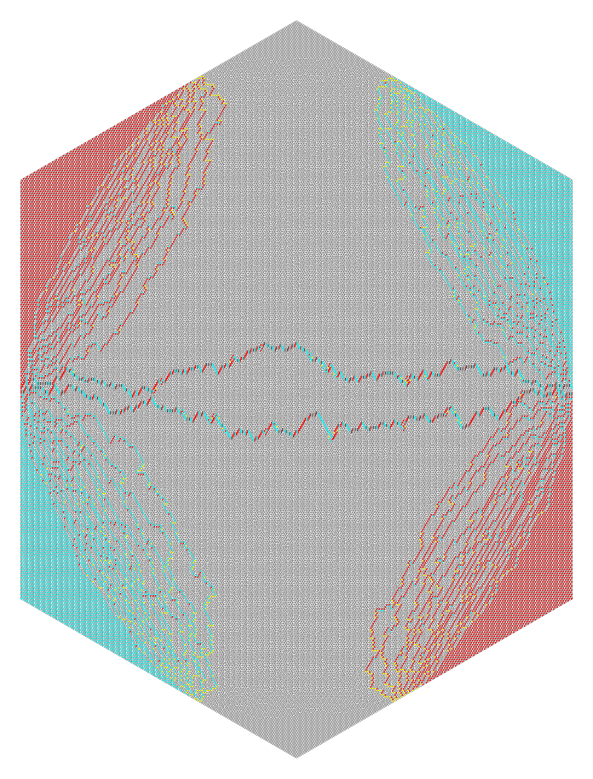

In [4]:
fig = draw_temperley_paths(H.get_edge_matrix(),int(round(1*n)),int(round(bc*n)),int(round(bc*n)),edge_width=0.05,dpi=200)